In [4]:
import pandas as pd
import warnings

# Отключаем предупреждения о парсинге дат, чтобы убрать розовые блоки
warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

# 1. Загрузка данных
df = pd.read_csv("tickets.csv", sep=";")

# 2. Исправление типов для идентификаторов и категорий
df["Назначенный агент"] = df["Назначенный агент"].astype("Int64")

categorical_cols = ["Канал запроса", "Текущий статус", "Приоритет", "Категория 1"]
df[categorical_cols] = df[categorical_cols].astype("category")


# 3. Преобразование даты и времени
df["Время получения"] = pd.to_datetime(df["Время получения"], dayfirst=True, errors="coerce")

# Объединяем Дату и Время первого ответа
df["Первый ответ"] = pd.to_datetime(
    df["Дата первого ответа"].astype(str).str.strip() + " " + df["Время первого ответа"].astype(str).str.strip(), 
    dayfirst=True, 
    errors="coerce"
)

# Объединяем Дату и Время первого комментария
df["Первый комментарий"] = pd.to_datetime(
    df["Дата первого комментария"].astype(str).str.strip() + " " + df["Время первого комментария"].astype(str).str.strip(), 
    dayfirst=True, 
    errors="coerce"
)

# Время выполнения и Последнее обновление статуса
df["Время выполнения"] = pd.to_datetime(df["Время выполнения"], dayfirst=True, errors="coerce")
df["Последнее обновление статуса"] = pd.to_datetime(df["Последнее обновление статуса"], dayfirst=True, errors="coerce")


# 4. Преобразование логического флага
df["Выполнен первым ответом"] = df["Выполнен первым ответом"].map({"Да": True, "Нет": False}).astype(bool)


# 5. Удаляем старые разрозненные колонки
old_date_time_cols = [
    "Дата первого ответа", "Время первого ответа", 
    "Дата первого комментария", "Время первого комментария"
]
df = df.drop(columns=old_date_time_cols)

# 6. Проверяем результат
df.info()

/var/folders/6w/08ybpswj1jz3_bh79s6k7jwc0000gn/T/ipykernel_16136/1896118601.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Первый ответ"] = pd.to_datetime(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8297 entries, 0 to 8296
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Номер запроса                 8297 non-null   int64         
 1   Время получения               8297 non-null   datetime64[ns]
 2   Канал запроса                 8297 non-null   category      
 3   Имя клиента                   8297 non-null   object        
 4   Email клиента                 0 non-null      float64       
 5   Тема запроса                  8297 non-null   object        
 6   Текущий статус                8297 non-null   category      
 7   Последнее обновление статуса  8297 non-null   datetime64[ns]
 8   Приоритет                     8285 non-null   category      
 9   Назначенный агент             8188 non-null   Int64         
 10  Время выполнения              8291 non-null   datetime64[ns]
 11  Выполнен первым ответом       

/var/folders/6w/08ybpswj1jz3_bh79s6k7jwc0000gn/T/ipykernel_16136/1896118601.py:28: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Первый комментарий"] = pd.to_datetime(
/var/folders/6w/08ybpswj1jz3_bh79s6k7jwc0000gn/T/ipykernel_16136/1896118601.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Время выполнения"] = pd.to_datetime(df["Время выполнения"], dayfirst=True, errors="coerce")


Статистика времени выполнения тикетов (в часах):
count    8291.000000
mean     1886.398432
std       217.914551
min      1512.532778
25%      1693.295278
50%      1895.376944
75%      2069.596667
max      2256.153056
Name: Время_выполнения_ч, dtype: float64


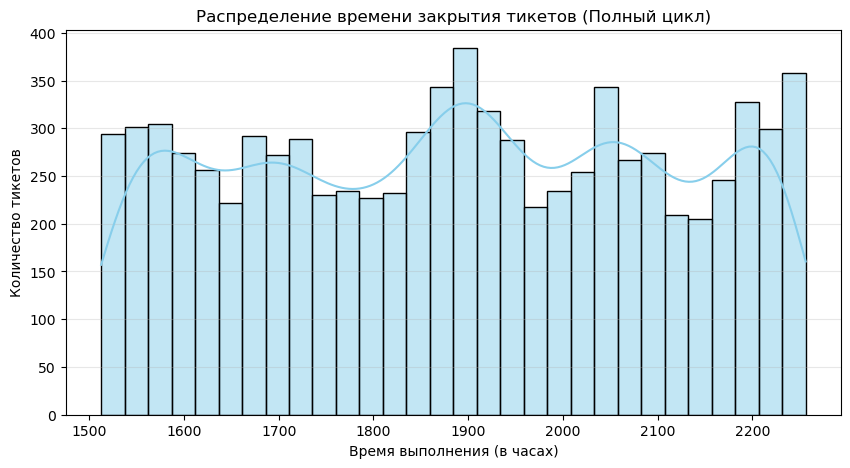

In [9]:
#Анализ SLA: Сколько времени уходит на решение запроса?
#Бизнес-контекст: Нам нужно посчитать метрику 
#Resolution Time — разницу между получением тикета и его закрытием, а также понять, как быстро агенты дают первый ответ.

import matplotlib.pyplot as plt
import seaborn as sns

# Рассчитываем время до первого ответа и полное время выполнения в часах
df['Время_до_первого_ответа_ч'] = (df['Первый ответ'] - df['Время получения']).dt.total_seconds() / 3600
df['Время_выполнения_ч'] = (df['Время выполнения'] - df['Время получения']).dt.total_seconds() / 3600

# Строим общую статистику по времени выполнения
print("Статистика времени выполнения тикетов (в часах):")
print(df['Время_выполнения_ч'].describe())

# Строим график без жесткого ограничения в 72 часа
plt.figure(figsize=(10, 5))
# Расширяем диапазон под твои данные (от 1500 до 2300 часов)
sns.histplot(df['Время_выполнения_ч'], bins=30, kde=True, color='skyblue')

plt.title('Распределение времени закрытия тикетов (Полный цикл)')
plt.xlabel('Время выполнения (в часах)')
plt.ylabel('Количество тикетов')
plt.grid(axis='y', alpha=0.3)
plt.show()


In [10]:
# Смотрим на первые 5 строк: исходные колонки и результат нашей конвертации
check_df = df[[
    'Время получения', 
    'Время выполнения', 
    'Время_выполнения_ч'
]].head(5)

print("Проверка расчета времени выполнения:")
print(check_df.to_string())

Проверка расчета времени выполнения:
      Время получения    Время выполнения  Время_выполнения_ч
0 2026-04-01 16:33:00 2026-06-06 00:13:35         1567.676389
1 2026-04-03 11:32:00 2026-06-06 00:46:52         1525.247778
2 2026-04-02 19:49:00 2026-06-06 00:29:12         1540.670000
3 2026-04-03 13:56:00 2026-06-06 00:23:08         1522.452222
4 2026-04-03 17:49:00 2026-06-06 00:54:58         1519.099444


In [11]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="pandas")

# 1. Загрузка данных заново
df = pd.read_csv("tickets.csv", sep=";")

# 2. Исправление типов
df["Назначенный агент"] = df["Назначенный агент"].astype("Int64")
categorical_cols = ["Канал запроса", "Текущий статус", "Приоритет", "Категория 1"]
df[categorical_cols] = df[categorical_cols].astype("category")

# 3. Корректное преобразование дат
# Время получения преобразуем как полноценную дату
df["Время получения"] = pd.to_datetime(df["Время получения"], dayfirst=True, errors="coerce")

# Склейка даты и времени первого ответа/комментария
df["Первый ответ"] = pd.to_datetime(
    df["Дата первого ответа"].astype(str).str.strip() + " " + df["Время первого ответа"].astype(str).str.strip(), 
    dayfirst=True, errors="coerce"
)
df["Первый комментарий"] = pd.to_datetime(
    df["Дата первого комментария"].astype(str).str.strip() + " " + df["Время первого комментария"].astype(str).str.strip(), 
    dayfirst=True, errors="coerce"
)
df["Последнее обновление статуса"] = pd.to_datetime(df["Последнее обновление статуса"], dayfirst=True, errors="coerce")

# !!! ИСПРАВЛЕНИЕ: Переводим 'Время выполнения' в формат timedelta (продолжительность)
# Pandas поймет текстовый формат 'ЧЧ:ММ:СС' как чистую длительность
df["Время выполнения"] = pd.to_timedelta(df["Время выполнения"], errors="coerce")


# 4. Преобразование логического флага
df["Выполнен первым ответом"] = df["Выполнен первым ответом"].map({"Да": True, "Нет": False}).astype(bool)

# 5. Удаляем старые разрозненные колонки
old_date_time_cols = ["Дата первого ответа", "Время первого ответа", "Дата первого комментария", "Время первого комментария"]
df = df.drop(columns=old_date_time_cols)

# 6. Проверяем типы данных
df.info()

/var/folders/6w/08ybpswj1jz3_bh79s6k7jwc0000gn/T/ipykernel_16136/772157431.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Первый ответ"] = pd.to_datetime(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8297 entries, 0 to 8296
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype          
---  ------                        --------------  -----          
 0   Номер запроса                 8297 non-null   int64          
 1   Время получения               8297 non-null   datetime64[ns] 
 2   Канал запроса                 8297 non-null   category       
 3   Имя клиента                   8297 non-null   object         
 4   Email клиента                 0 non-null      float64        
 5   Тема запроса                  8297 non-null   object         
 6   Текущий статус                8297 non-null   category       
 7   Последнее обновление статуса  8297 non-null   datetime64[ns] 
 8   Приоритет                     8285 non-null   category       
 9   Назначенный агент             8188 non-null   Int64          
 10  Время выполнения              8297 non-null   timedelta64[ns]
 11  Выполнен первым о

/var/folders/6w/08ybpswj1jz3_bh79s6k7jwc0000gn/T/ipykernel_16136/772157431.py:23: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Первый комментарий"] = pd.to_datetime(


Новая корректная статистика времени выполнения тикетов (в часах):
count    8297.000000
mean        0.455221
std         1.941553
min         0.000000
25%         0.201111
50%         0.337222
75%         0.537778
max        79.970833
Name: Время_выполнения_ч, dtype: float64


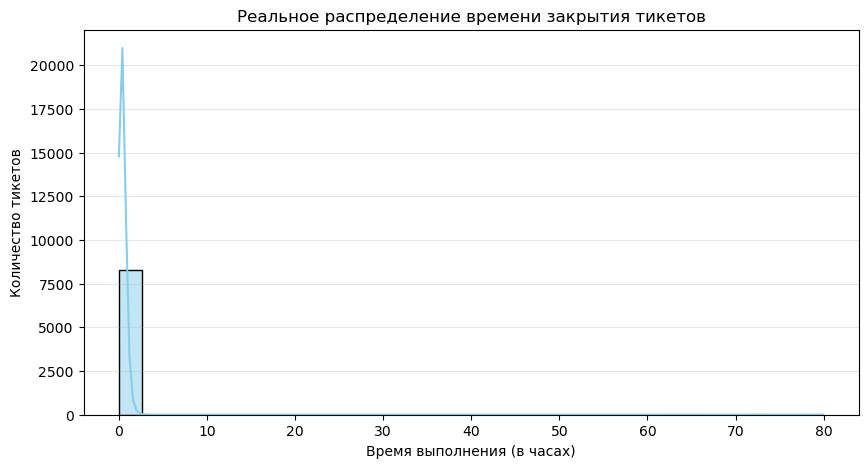

In [12]:
# Переводим длительность выполнения в часы напрямую
df['Время_выполнения_ч'] = df['Время выполнения'].dt.total_seconds() / 3600
df['Время_до_первого_ответа_ч'] = (df['Первый ответ'] - df['Время получения']).dt.total_seconds() / 3600

print("Новая корректная статистика времени выполнения тикетов (в часах):")
print(df['Время_выполнения_ч'].describe())

# Строим новый график
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
# Теперь данные будут кучными и реальными, без искусственных 1500 часов
sns.histplot(df['Время_выполнения_ч'].dropna(), bins=30, kde=True, color='skyblue')

plt.title('Реальное распределение времени закрытия тикетов')
plt.xlabel('Время выполнения (в часах)')
plt.ylabel('Количество тикетов')
plt.grid(axis='y', alpha=0.3)
plt.show()

--- Детальная статистика по всем статусам ---
                Количество тикетов  Процент (%)
Текущий статус                                 
Закрыт                        8264        99.60
На удержании                    29         0.35
Объединен                        2         0.02
В ожидании                       1         0.01
Рассылка                         1         0.01


--- Соотношение завершенных тикетов и оставшихся в работе ---
Группа статусов
Завершенные (Закрыт/Выполнен)    99.6
В работе / Другие                 0.4 %


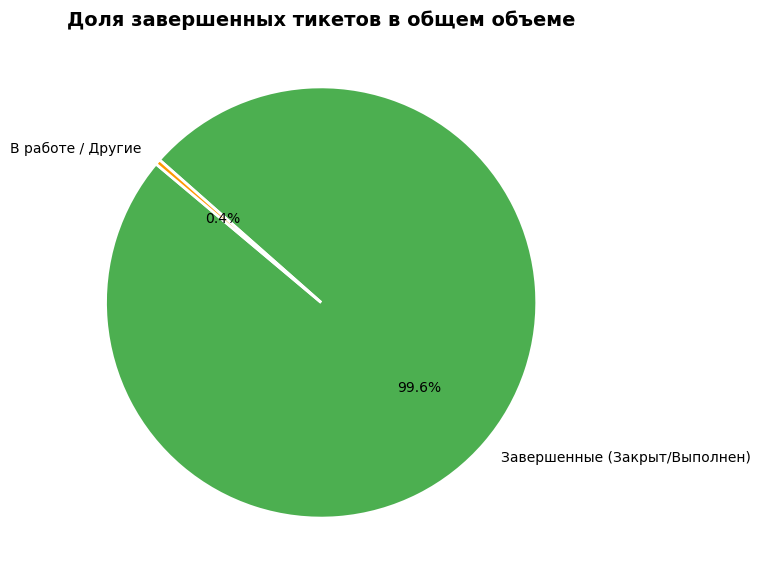

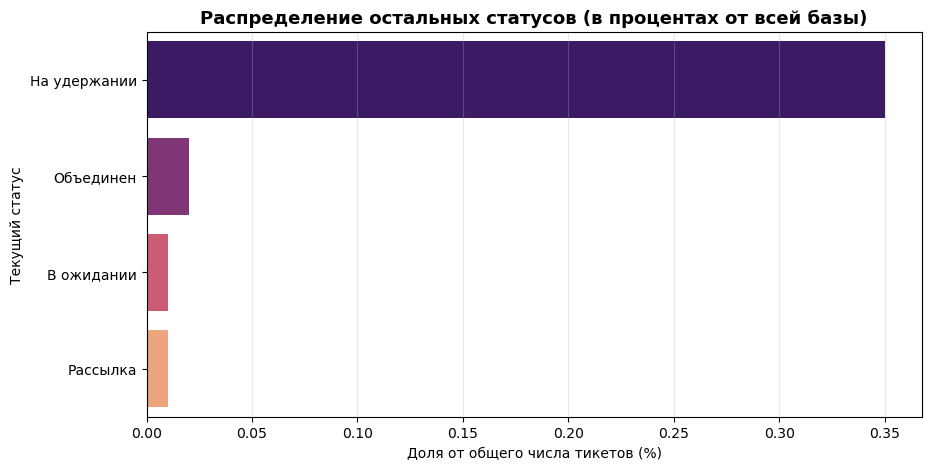

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка и базовая предобработка (чтобы типы были верными)
df = pd.read_csv("tickets.csv", sep=";")

# Убираем лишние пробелы в текстовых статусах, если они есть
df['Текущий статус'] = df['Текущий статус'].astype(str).str.strip()

# 2. Создаем укрупненную группу статусов
def categorize_status(status):
    if status in ['Закрыт', 'Выполнен']:
        return 'Завершенные (Закрыт/Выполнен)'
    else:
        return 'В работе / Другие'

df['Группа статусов'] = df['Текущий статус'].apply(categorize_status)

# 3. Считаем детальный процент по каждому статусу в датасете
status_counts = df['Текущий статус'].value_counts()
status_pct = df['Текущий статус'].value_counts(normalize=True) * 100

status_summary = pd.DataFrame({
    'Количество тикетов': status_counts,
    'Процент (%)': status_pct
}).round(2)

print("--- Детальная статистика по всем статусам ---")
print(status_summary)
print("\n" + "="*50 + "\n")

# 4. Считаем соотношение укрупненных групп
group_summary = df['Группа статусов'].value_counts(normalize=True) * 100
print("--- Соотношение завершенных тикетов и оставшихся в работе ---")
print(group_summary.round(2).to_string() + " %")

# ==========================================
# ВИЗУАЛИЗАЦИЯ
# ==========================================

# График 1: Круговая диаграмма (Pie Chart) для укрупненных групп
plt.figure(figsize=(7, 7))
colors = ['#4CAF50', '#FF9800'] # Зеленый для завершенных, Оранжевый для тех, что в работе
plt.pie(group_summary, labels=group_summary.index, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'antialiased': True})
plt.title('Доля завершенных тикетов в общем объеме', fontsize=14, fontweight='bold')
plt.show()

# График 2: Горизонтальный Bar Chart для детальных статусов (кроме Закрыт и Выполнен)
# Это подсветит, каких именно "других" статусов больше всего
other_statuses = status_summary[~status_summary.index.isin(['Закрыт', 'Выполнен'])]

if not other_statuses.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=other_statuses['Процент (%)'], y=other_statuses.index, palette='magma', hue=other_statuses.index, legend=False)
    plt.title('Распределение остальных статусов (в процентах от всей базы)', fontsize=13, fontweight='bold')
    plt.xlabel('Доля от общего числа тикетов (%)')
    plt.ylabel('Текущий статус')
    plt.grid(axis='x', alpha=0.3)
    plt.show()
else:
    print("В датасете нет других статусов, кроме 'Закрыт' и 'Выполнен'.")

--- Распределение приоритетов среди задач В РАБОТЕ ---
Приоритет
Средний    100.0 %


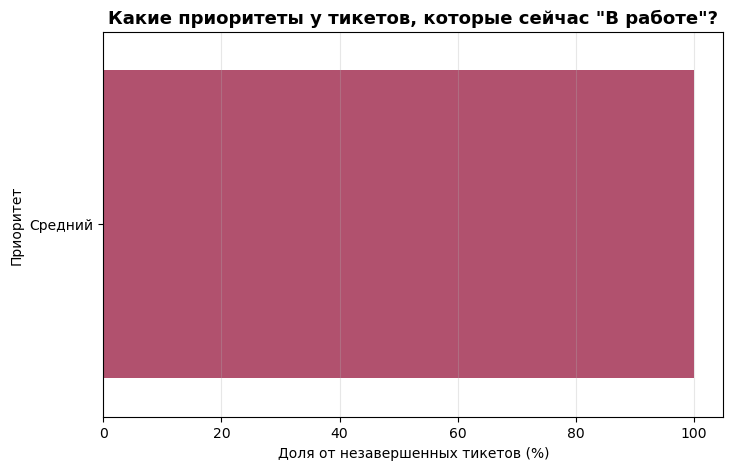

In [14]:
# Фильтруем только незавершенные тикеты
unresolved_df = df[df['Группа статусов'] == 'В работе / Другие']

# Считаем распределение приоритетов среди незавершенных задач
priority_dist = unresolved_df['Приоритет'].value_counts(normalize=True) * 100

print("--- Распределение приоритетов среди задач В РАБОТЕ ---")
print(priority_dist.round(2).to_string() + " %")

# Визуализация
plt.figure(figsize=(8, 5))
sns.barplot(x=priority_dist.values, y=priority_dist.index, palette='flare', hue=priority_dist.index, legend=False)
plt.title('Какие приоритеты у тикетов, которые сейчас "В работе"?', fontsize=13, fontweight='bold')
plt.xlabel('Доля от незавершенных тикетов (%)')
plt.ylabel('Приоритет')
plt.grid(axis='x', alpha=0.3)
plt.show()

--- Процент завершенных и открытых тикетов по каналам связи ---
Группа статусов    В работе / Другие  Завершенные (Закрыт/Выполнен)
Канал запроса                                                      
Whatsapp                        0.40                          99.60
facebook                        0.00                         100.00
instagram                       0.00                         100.00
vk                              0.00                         100.00
Чатбот - telegram               0.44                          99.56


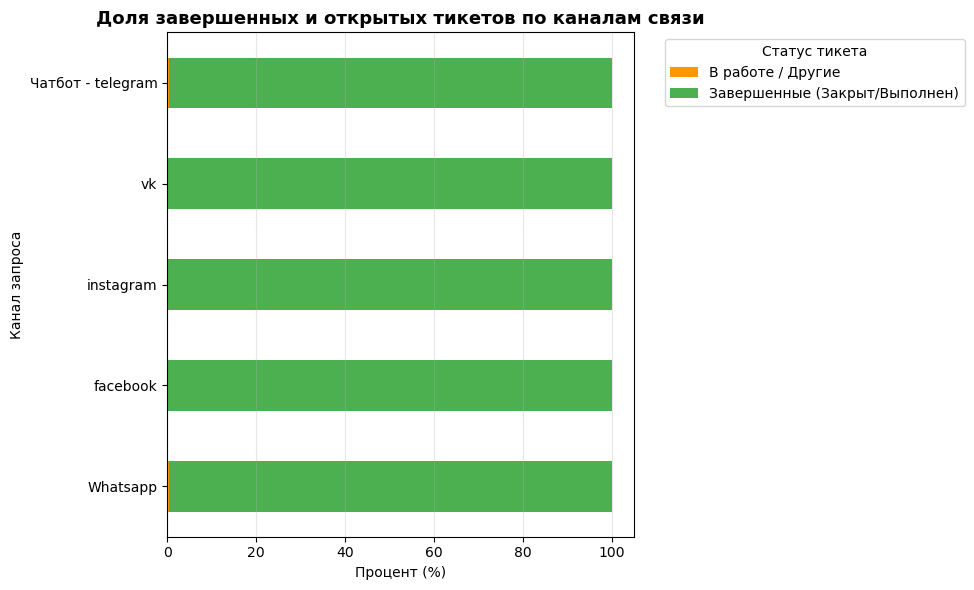

In [15]:
# Строим кросс-таблицу: Группа статусов в разрезе Каналов запроса
channel_status = pd.crosstab(df['Канал запроса'], df['Группа статусов'], normalize='index') * 100

print("--- Процент завершенных и открытых тикетов по каналам связи ---")
print(channel_status.round(2))

# Визуализация в виде накопленной столбчатой диаграммы (Stacked Bar Chart)
channel_status.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#FF9800', '#4CAF50'])
plt.title('Доля завершенных и открытых тикетов по каналам связи', fontsize=13, fontweight='bold')
plt.xlabel('Процент (%)')
plt.ylabel('Канал запроса')
plt.legend(title='Статус тикета', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

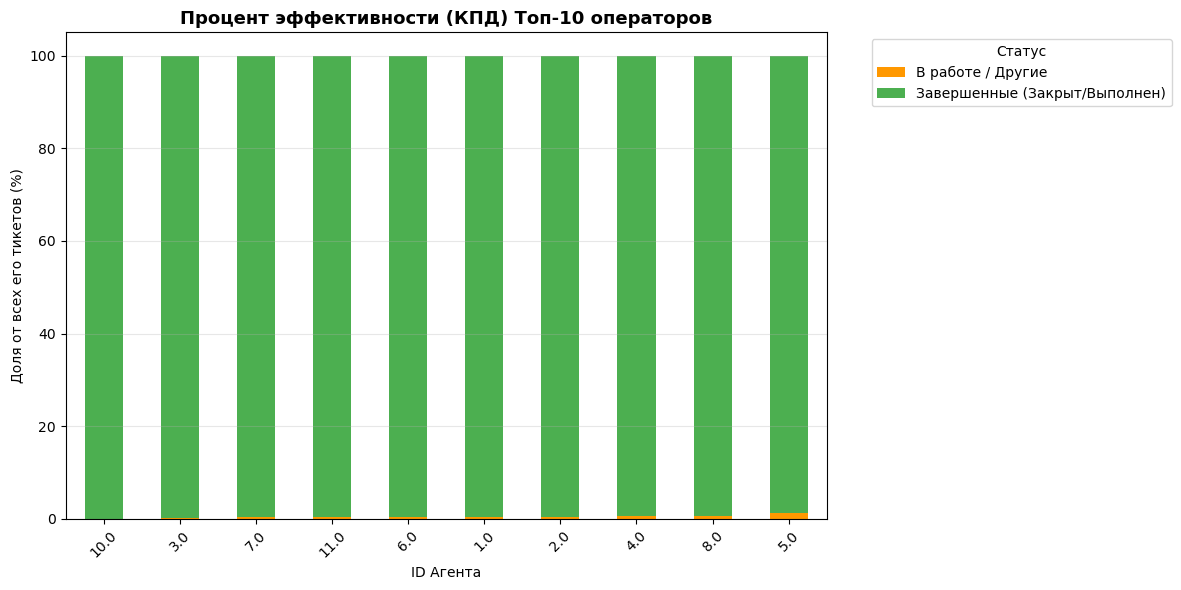

In [16]:
# Определяем топ-10 самых нагруженных агентов
top_agents = df['Назначенный агент'].value_counts().head(10).index

# Фильтруем датасет только по этим агентам
df_top_agents = df[df['Назначенный агент'].isin(top_agents)]

# Строим таблицу распределения групп статусов для топ-агентов
agent_status = pd.crosstab(df_top_agents['Назначенный агент'], df_top_agents['Группа статусов'], normalize='index') * 100

# Сортируем по доле завершенных для наглядности
agent_status = agent_status.sort_values(by='Завершенные (Закрыт/Выполнен)', ascending=False)

# Визуализация
agent_status.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#FF9800', '#4CAF50'])
plt.title('Процент эффективности (КПД) Топ-10 операторов', fontsize=13, fontweight='bold')
plt.xlabel('ID Агента')
plt.ylabel('Доля от всех его тикетов (%)')
plt.xticks(rotation=45)
plt.legend(title='Статус', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

--- Распределение обращений по каналам связи ---
                   Количество тикетов  Доля (%)
Канал запроса                                  
Whatsapp                         5764     69.47
Чатбот - telegram                2259     27.23
instagram                         190      2.29
facebook                           47      0.57
vk                                 37      0.45


--- ТОП-10 тематик обращений ---
  Тематика (Категория 1)  Количество запросов
0           Консультация                 5617
1               Проблема                 1450
2    Диалог не состоялся                 1025
3                   Тест                  110


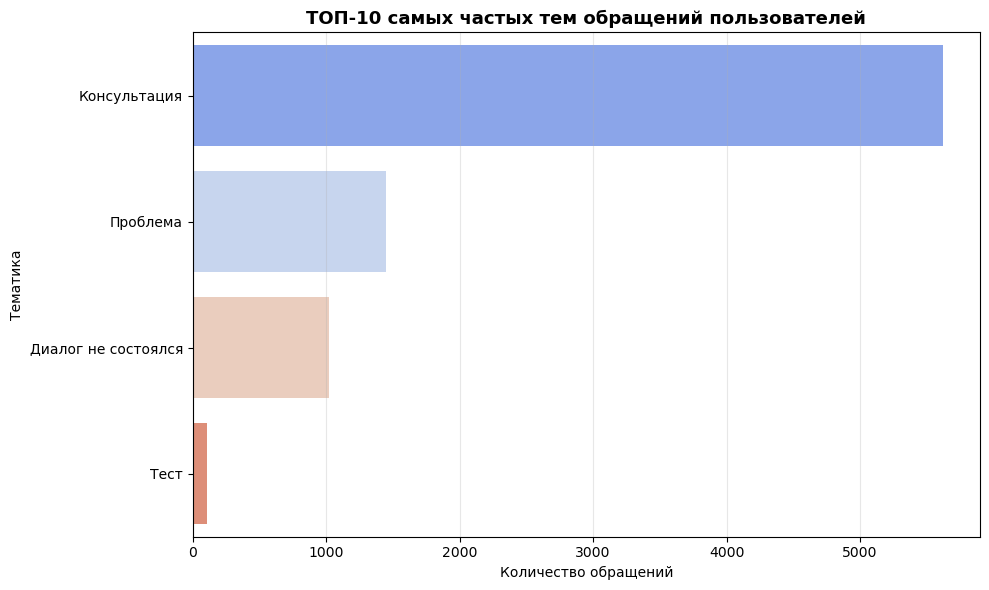

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Считаем количество и процент обращений по каналам связи
channel_counts = df['Канал запроса'].value_counts()
channel_pct = df['Канал запроса'].value_counts(normalize=True) * 100

channel_summary = pd.DataFrame({
    'Количество тикетов': channel_counts,
    'Доля (%)': channel_pct
}).round(2)

print("--- Распределение обращений по каналам связи ---")
print(channel_summary)
print("\n" + "="*50 + "\n")

# 2. Считаем топ-10 самых частых тематик (Категория 1)
top_categories = df['Категория 1'].value_counts().head(10).reset_index()
top_categories.columns = ['Тематика (Категория 1)', 'Количество запросов']

print("--- ТОП-10 тематик обращений ---")
print(top_categories)

# Визуализация ТОП-10 тематик
plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories, x='Количество запросов', y='Тематика (Категория 1)', palette='coolwarm', hue='Тематика (Категория 1)', legend=False)
plt.title('ТОП-10 самых частых тем обращений пользователей', fontsize=13, fontweight='bold')
plt.xlabel('Количество обращений')
plt.ylabel('Тематика')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

--- Матрица распределения тематик по каналам (в штуках) ---
Канал запроса        Whatsapp  facebook  instagram  vk  Чатбот - telegram
Категория 1                                                              
Диалог не состоялся       685        36        157   7                140
Консультация             4024         6         16  15               1556
Проблема                  931         3          8   3                505
Тест                       45         2          7  11                 45


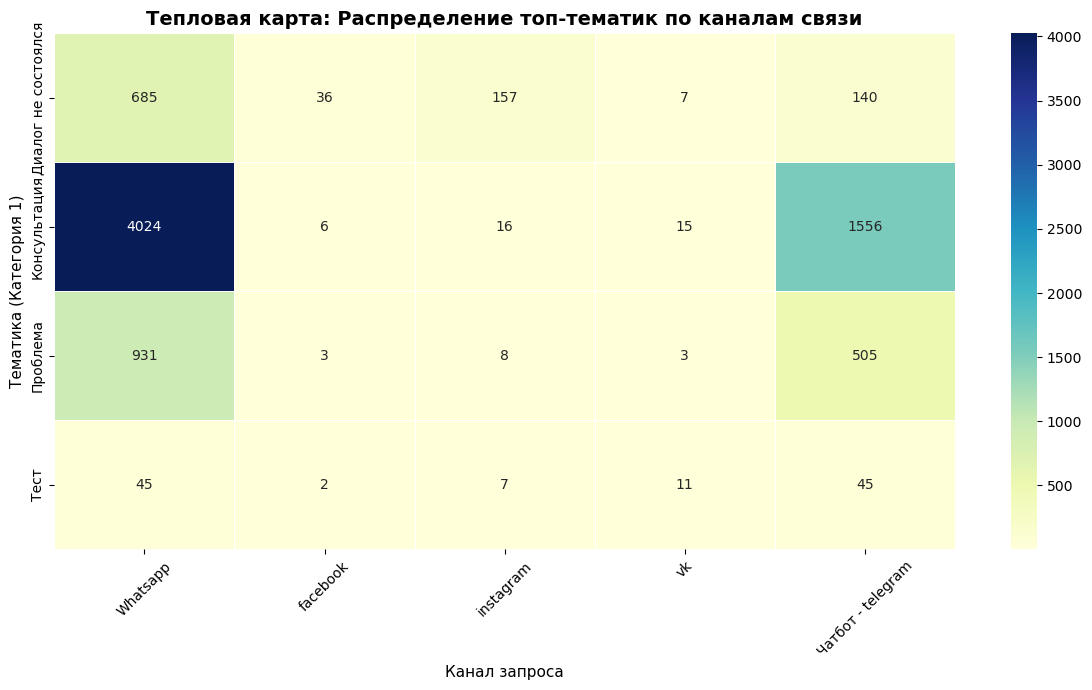

In [18]:
# Определяем топ-7 самых частых категорий, чтобы график был читаемым
top_7_cats = df['Категория 1'].value_counts().head(7).index

# Фильтруем датасет только по этим топ-категориям
df_filtered_cats = df[df['Категория 1'].isin(top_7_cats)]

# Строим таблицу сопряженности (количество тикетов на пересечении Канала и Категории)
pivot_table = pd.crosstab(df_filtered_cats['Категория 1'], df_filtered_cats['Канал запроса'])

print("--- Матрица распределения тематик по каналам (в штуках) ---")
print(pivot_table)

# Визуализация тепловой карты (Heatmap)
plt.figure(figsize=(12, 7))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu", cbar=True, linewidths=0.5)
plt.title('Тепловая карта: Распределение топ-тематик по каналам связи', fontsize=14, fontweight='bold')
plt.xlabel('Канал запроса', fontsize=11)
plt.ylabel('Тематика (Категория 1)', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

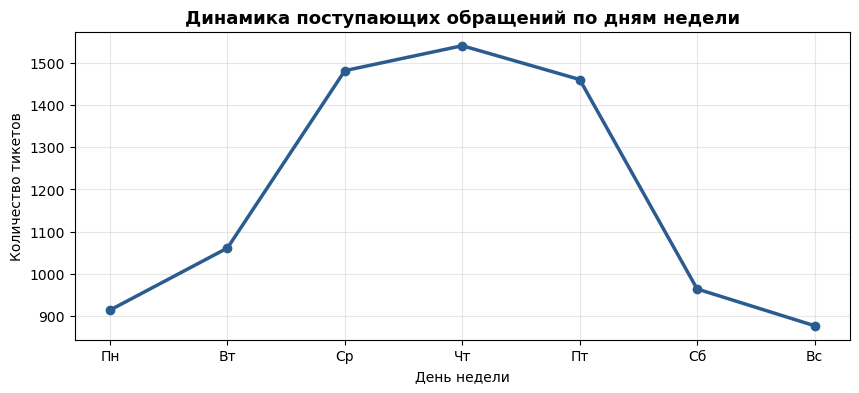

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Принудительно переводим колонку в формат даты (исправляет ошибку .dt)
df['Время получения'] = pd.to_datetime(df['Время получения'], dayfirst=True, errors='coerce')

# 2. Достаем день недели (0 = Понедельник, 6 = Воскресенье)
df['День недели'] = df['Время получения'].dt.dayofweek

# 3. Создаем понятные текстовые названия дней
days_map = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
df['День недели назв'] = df['День недели'].map(days_map)

# 4. Считаем количество тикетов по дням и сортируем по порядку недели
daily_tickets = df['День недели назв'].value_counts().reindex(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])

# 5. Визуализация тренда нагрузки
plt.figure(figsize=(10, 4))
plt.plot(daily_tickets.index, daily_tickets.values, marker='o', color='#2b5c8f', linewidth=2.5)
plt.title('Динамика поступающих обращений по дням недели', fontsize=13, fontweight='bold')
plt.xlabel('День недели')
plt.ylabel('Количество тикетов')
plt.grid(True, alpha=0.3)
plt.show()